In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

In [4]:
df = pd.read_csv('india_city_aqi_2015_2023-cleaned_dataset.csv')
df["aqi_category"] = df["aqi_category"].replace({
    "Poor": "Moderate"
})
df['aqi_category'].value_counts()

aqi_category
Satisfactory    17244
Moderate        11443
Good             4183
Name: count, dtype: int64

In [5]:
df.head(10)

,city,date,pm2.5,pm10,no2,so2,co,o3,aqi,aqi_category,pm2.5/pm10 ratio,season
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate,0.678901,Winter
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate,0.686603,Winter
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory,0.884291,Winter
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good,0.667539,Winter
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory,0.527192,Winter
5,Delhi,2015-01-06,55.931736,142.977299,39.797542,6.711445,1.046763,31.687345,78,Satisfactory,0.391193,Winter
6,Delhi,2015-01-07,88.354544,99.161141,20.077209,12.984306,1.021540,52.570524,81,Satisfactory,0.891020,Winter
7,Delhi,2015-01-08,75.374069,119.351995,17.822170,8.400779,0.661808,65.856833,81,Satisfactory,0.631528,Winter
8,Delhi,2015-01-09,93.744732,108.483929,44.861260,10.074589,0.596923,59.175144,89,Satisfactory,0.864135,Winter
9,Delhi,2015-01-10,121.239981,189.865583,27.411737,10.453938,0.899379,64.633177,126,Moderate,0.638557,Winter


In [6]:
# Features

features = [
    'pm2.5',
    'pm10',
    'no2',
    'so2',
    'co',
    'o3',
    'season'
 ]

X = df[features]
X = pd.get_dummies(X, columns=['season']) # season -> one hot encoded


In [7]:
# Target encoding
from sklearn.preprocessing import LabelEncoder

y = df['aqi_category']
le = LabelEncoder()
y = le.fit_transform(y)

pd.Series(y).head(5)

0    1
1    1
2    2
3    0
4    2
dtype: int64

In [8]:
X.head(10)

,pm2.5,pm10,no2,so2,co,o3,season_Monsoon,season_Post-Monsoon,season_Summer,season_Winter
0,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,False,False,False,True
1,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,False,False,False,True
2,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,False,False,False,True
3,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,False,False,False,True
4,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,False,False,False,True
5,55.931736,142.977299,39.797542,6.711445,1.046763,31.687345,False,False,False,True
6,88.354544,99.161141,20.077209,12.984306,1.021540,52.570524,False,False,False,True
7,75.374069,119.351995,17.822170,8.400779,0.661808,65.856833,False,False,False,True
8,93.744732,108.483929,44.861260,10.074589,0.596923,59.175144,False,False,False,True
9,121.239981,189.865583,27.411737,10.453938,0.899379,64.633177,False,False,False,True


In [9]:
# Class label mapping (original -> encoded)
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
class_mapping

{'Good': np.int64(0), 'Moderate': np.int64(1), 'Satisfactory': np.int64(2)}

In [10]:
print(X.shape,y.shape)

(32870, 10) (32870,)


In [11]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [12]:
# Training Random Forest Model

rf_model = RandomForestClassifier(

    n_estimators=200,      # number of trees
    max_depth=12,          # depth of each tree
    min_samples_split=5,   # minimum samples to split node
    min_samples_leaf=2,    # minimum samples in leaf node
    criterion="entropy",   # options: "gini", "entropy", "log_loss"
    random_state=42

)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [13]:
# Making AQI Predictions category

y_pred_rf = rf_model.predict(X_test)

In [14]:
# Evaluated Model's Peformance based on Accuracy

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))



Accuracy: 0.9875266200182538

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       837
           1       0.99      0.99      0.99      2288
           2       0.99      0.99      0.99      3449

    accuracy                           0.99      6574
   macro avg       0.99      0.98      0.98      6574
weighted avg       0.99      0.99      0.99      6574



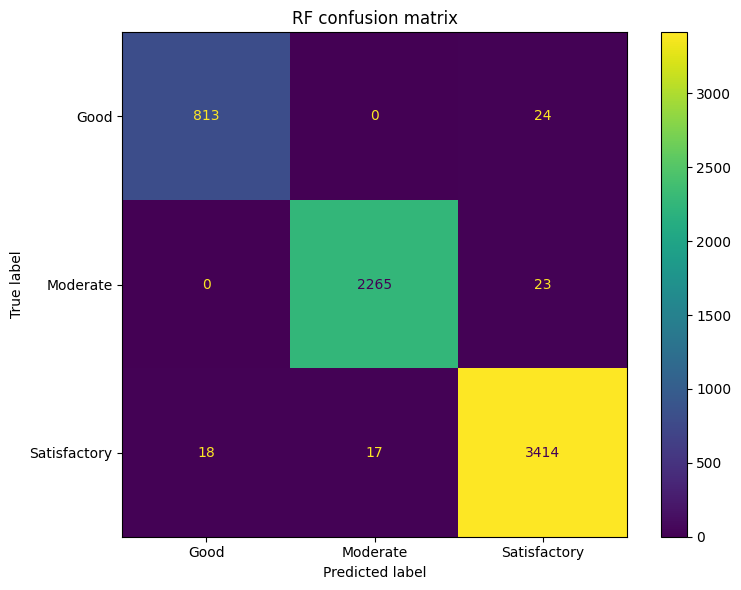

In [15]:
# RF confusion matrix plot
labels = ["Good", "Moderate", "Satisfactory"]
cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="viridis", colorbar=True, values_format="d")

plt.title("RF confusion matrix")
plt.tight_layout()
plt.show()

In [16]:
# Feature Engineering -> Random forest provides automatic feature importance

importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
    )
print(feature_importance)


               Feature  Importance
0                pm2.5    0.567736
1                 pm10    0.385348
5                   o3    0.015104
2                  no2    0.014558
4                   co    0.007219
3                  so2    0.007200
9        season_Winter    0.000741
8        season_Summer    0.000731
6       season_Monsoon    0.000698
7  season_Post-Monsoon    0.000664


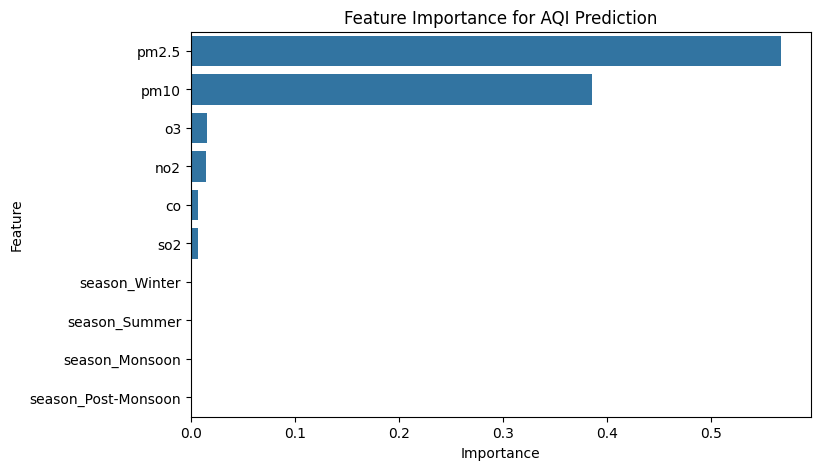

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance for AQI Prediction")
plt.show()